In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

df_LR_assembly_metadata = pd.read_csv("../../data/TRUST.PBAsm.ZA_106CI_AssemblySummary.csv")
df_LR_assembly_metadata['Lineage'] = df_LR_assembly_metadata['Lineage_Asm'].str.replace('lineage', '')

# this keeps only those with NumContigs = 1 and numContigs_Complete = 1 in df_LR_assembly_metadata, and the lineages (Coll2014 exactly) of the LR and SR sequences must match
df_personal_assemblies = pd.read_csv("../data/personal_assemblies_samples.tsv", sep='\t', header=None, names = ['Sample', 'Assembly', 'PacBio'])
samples_with_assemblies = df_personal_assemblies['Sample'].values

df_trust_patients = pd.read_csv("~/TRUST_data_processing/processed_data/20250904_cleaned_patient_outcomes_data.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
F2_thresh = 0.03

unmixed_lineage_samples = df_trust_patients.query("F2 <= @F2_thresh").SampleID.unique()

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

In [47]:
# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))

rrs
rrl
rrf


# Get the Input data

In [59]:
model_dir = "model_1/"

df_trust_patients = pd.read_csv("~/TRUST_data_processing/processed_data/20250904_cleaned_patient_outcomes_data.csv")
unmixed_lineage_samples = df_trust_patients.query("F2 <= 0.03").SampleID.unique()

lowAF_directory = H37Rv_ref_dir
ground_truth_directory = personal_ref_dir

if not os.path.isdir(lowAF_directory):
    raise ValueError(f"{lowAF_directory} is not an available directory")
    
if not os.path.isdir(ground_truth_directory):
    raise ValueError(f"{ground_truth_directory} is not an available directory")

SNP_data_files = glob.glob(f"{lowAF_directory}/*/freebayes/lowAF_SNPs.csv")

df_candidate_SNPs = []

for fName in SNP_data_files:
    
    match = re.search(r'MFS-\d{1,3}', fName)
    
    if match.group() in unmixed_lineage_samples:
        
        df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")        
        df['SampleID'] = match.group()
        df_candidate_SNPs.append(df)
    
df_candidate_SNPs = pd.concat(df_candidate_SNPs)

# these are the samples with ground truth data (hybrid assemblies)
df_personal_assemblies = pd.read_csv("../data/personal_assemblies_samples.tsv", sep='\t', header=None)

samples_with_ground_truth = df_personal_assemblies[0].values

ground_truth_SNP_data_files = glob.glob(f"{ground_truth_directory}/*/lowAF_comparison/ground_truth.csv")

df_ground_truth = []

for fName in ground_truth_SNP_data_files:
    
    match = re.search(r'MFS-\d{1,3}', fName)
    
    if match.group() in unmixed_lineage_samples:
        
        df = pd.read_csv(fName).query("REF.str.len() == ALT.str.len()")
        df['SampleID'] = match.group()
        df_ground_truth.append(df)
    
df_ground_truth = pd.concat(df_ground_truth)
df_ground_truth['Real'] = 1

# remove rRNA pos, which have too many false positives due to contamination
df_candidate_SNPs = df_candidate_SNPs.query("POS not in @rRNA_pos")

# merge the candidate SNPs from Illumina sequencing with the ground truth information from the hybrid assemblies, but only for samples with hybrid assemblies
# only merge on POS because of differences in the minor allele relative to the personal assembly vs. H37Rv
df_candidate_SNPs_ground_truth = df_candidate_SNPs.query("SampleID in @samples_with_ground_truth").merge(df_ground_truth[['SampleID', 'POS', 'Real']], how='outer', on=['POS', 'SampleID'])

# merged outer to keep everything, so anything that didn't have overlap between candidate SNPs and ground truth is not real
df_candidate_SNPs_ground_truth['Real'] = df_candidate_SNPs_ground_truth['Real'].fillna(0).astype(int)


# ------------------------------------------------------------------------------------------------------------------------
# Build model using the samples with ground truth information
# ------------------------------------------------------------------------------------------------------------------------
predictors = ["COV_RATIO", "CLIPPED_BASES_RATIO", "DISCORDANT_READS_RATIO", "Mean_BQ_ALT_allele"]

# NAs are false negatives. Print them as sanity checks. The two that have been found so far are variants ~95%/5%, and the H37Rv calls are <5%, so they get filtered out
# basically a fixed variant though, so not really a false negative
print(df_candidate_SNPs_ground_truth.loc[pd.isnull(df_candidate_SNPs_ground_truth['COV_RATIO'])]['SampleID'].value_counts())

# assert len(df_candidate_SNPs_ground_truth.dropna(subset=predictors)) == len(df_candidate_SNPs_ground_truth)

df_candidate_SNPs_ground_truth = df_candidate_SNPs_ground_truth.dropna(subset=predictors)

# make sure all numeric types
df_candidate_SNPs_ground_truth[predictors + ['Real']] = df_candidate_SNPs_ground_truth[predictors + ['Real']].apply(pd.to_numeric, errors='coerce')

df_candidate_SNPs_ground_truth = df_candidate_SNPs_ground_truth.drop_duplicates(predictors).reset_index(drop=True)
df_candidate_SNPs_ground_truth.to_csv(f"{model_dir}/training_data.csv", index=False)

# Mean_BQ_ALT_allele column can be NA if when a complex variant was split, the defind variant 
df_val = df_candidate_SNPs.query("SampleID not in @samples_with_ground_truth")
df_val['Mean_BQ_ALT_allele'] = df_val['Mean_BQ_ALT_allele'].fillna(0)

# save all values to get predictions
df_val.to_csv(f"{model_dir}/validation_data.csv", index=False)

SampleID
MFS-129    2
Name: count, dtype: int64


In [56]:
df_candidate_SNPs_ground_truth.Real.value_counts()

Real
0    500
1    274
Name: count, dtype: int64

In [ ]:
search_samples = df_val.loc[pd.isnull(df_val[predictors[3]])].drop_duplicates(subset='POS').sort_values('POS')[['SampleID', 'POS', 'REF', 'ALT', 'AF']].query("AF <= 0.95").SampleID.unique()

df_val.loc[pd.isnull(df_val[predictors[3]])].drop_duplicates(subset='POS').sort_values('POS')[['SampleID', 'POS', 'REF', 'ALT', 'AF']].query("AF <= 0.95")

,SampleID,POS,REF,ALT,AF
1,MFS-829,88552,C,G,0.283737
2,MFS-123,1779208,G,C,0.146739
4,MFS-123,1779215,C,T,0.146739
28,MFS-766,3215625,T,C,0.917241
29,MFS-766,3215626,C,A,0.917241


In [33]:
# for sample in search_samples:
#     if not os.path.isfile(f"/home/sak0914/{sample}.dedup.bam.bai"):
#         shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam", f"/home/sak0914/{sample}.dedup.bam")
#         shutil.copy(f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam.bai", f"/home/sak0914/{sample}.dedup.bam.bai")

In [58]:
df_val[predictors].dropna()

,COV_RATIO,CLIPPED_BASES_RATIO,DISCORDANT_READS_RATIO,Mean_BQ_ALT_allele
0,0.738879,0.197279,0.040816,34.495327
1,0.973713,0.000000,0.027864,35.368421
0,0.784056,0.141935,0.012903,33.743363
0,0.945514,0.007194,0.021583,35.573913
1,0.943764,0.003759,0.033835,49.454545
...,...,...,...,...
2,0.738733,0.316514,0.013761,33.683544
3,1.006287,0.002062,0.030928,38.080000
0,0.698647,0.534954,0.048632,36.944444
0,0.784760,0.441696,0.038869,42.500000


In [8]:
df_candidate_SNPs_ground_truth

,POS,REF,ALT,QUAL,FILTER,NS,DP,DPB,AC,AN,...,Mean_BQ_ALT_allele,COV,COV_MAX_ROLLING_AVG,CLIPPED_BASES,DISCORDANT_READS,COV_RATIO,DISCORDANT_READS_RATIO,CLIPPED_BASES_RATIO,SampleID,Real
0,2076862,A,G,5.454550e-14,PASS,1,262,262.000,0,1,...,35.238095,273,282.25,1,5,0.967228,0.018315,0.003663,MFS-1,1
1,2591484,G,A,6.060740e+02,PASS,1,480,480.000,1,1,...,34.855634,608,635.78,5,140,0.956306,0.230263,0.008224,MFS-1,0
2,2592310,G,A,2.112290e+03,PASS,1,485,485.000,1,1,...,35.911439,530,593.36,1,117,0.893218,0.220755,0.001887,MFS-1,0
3,3851887,A,C,9.536250e+02,PASS,1,42,42.000,1,1,...,34.280702,70,165.06,75,2,0.424088,0.028571,1.071429,MFS-1,0
4,3851888,T,C,9.536250e+02,PASS,1,42,42.000,1,1,...,34.600000,70,163.44,75,2,0.428292,0.028571,1.071429,MFS-1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
769,1844169,G,T,0.000000e+00,PASS,1,331,331.000,0,1,...,36.608696,355,358.22,1,10,0.991011,0.028169,0.002817,MFS-97,1
770,2591484,G,A,0.000000e+00,PASS,1,475,475.000,0,1,...,36.274262,596,635.29,0,120,0.938154,0.201342,0.000000,MFS-97,0
771,2592310,G,A,3.027930e+03,PASS,1,502,502.000,1,1,...,36.225589,548,589.98,2,104,0.928845,0.189781,0.003650,MFS-97,0
772,3851887,A,C,3.585240e+03,PASS,1,130,130.333,1,1,...,36.883721,160,197.52,20,1,0.810045,0.006250,0.125000,MFS-97,0


# Fit a Linear Mixed Effects Model

Did this in R

Sample = random effect. 

Do we need an additional random effect for patient because some of the samples come from the same patient?

In [62]:
model_dir = "model_1/"

df_trust_patients = pd.read_csv("~/TRUST_data_processing/processed_data/20250904_cleaned_patient_outcomes_data.csv")

df_train = pd.read_csv(f"{model_dir}/training_data.csv")

df_val = pd.read_csv(f"{model_dir}/validation_data.csv")

linear_mixed_model_predictions = pd.read_csv(f"{model_dir}/linear_mixed_model_predictions.csv")
print(len(linear_mixed_model_predictions))

# linear_mixed_model_predictions = linear_mixed_model_predictions.merge(df_trust_patients[['pid', 'Original_ID', 'SampleID', 'Sampling_Week']] on='SampleID', how='outer')

assert sum(pd.isnull(linear_mixed_model_predictions['predicted'])) == 0

linear_mixed_model_predictions.pred_class.value_counts()

7626


pred_class
1    4889
0    2737
Name: count, dtype: int64

# Analyze the Posteriors

In [5]:
posterior_summary = pd.read_csv(f"{model_dir}/posterior_summary.csv", index_col=[0])

# p_dim_0 is the sample index. Number of unique values = len(train_idx)
posterior_samples = pd.read_csv(f"{model_dir}/posterior_samples.csv")

# should be close to 1 for convergence
posterior_summary.r_hat.value_counts()

r_hat
1.0    618
Name: count, dtype: int64

In [57]:
df_pred = pd.DataFrame({'y_hat': posterior_samples.groupby('p_dim_0')['p'].mean(), 'y_true': y_train})

In [59]:
df_pred.groupby('y_true')['y_hat'].mean()

y_true
0    0.346836
1    0.377033
Name: y_hat, dtype: float64

<Axes: xlabel='y_true', ylabel='y_hat'>

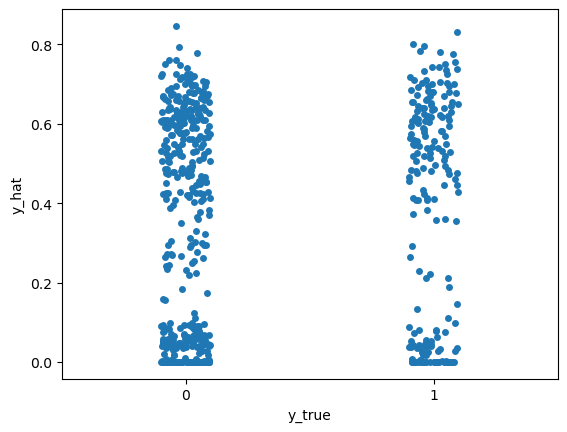

In [58]:
sns.stripplot(data=df_pred,
               x='y_true',
              y='y_hat'
               )

In [42]:
# Convert to numpy arrays
intercept = posterior_samples["intercept"].values  # shape (chains, draws)
beta_cov = posterior_samples["beta_cov"].values
beta_soft = posterior_samples["beta_soft"].values
beta_disc = posterior_samples["beta_disc"].values
beta_bq = posterior_samples["beta_bq"].values

# Stack into (n_samples, n_features)
n_chains = posterior_samples.chain.nunique()
n_draws = posterior_samples.draw.nunique()
n_samples = n_chains * n_draws

n_chains, n_draws

(4, 2000)

In [47]:
posterior_samples.query("chain==0 & draw==1")

,chain,draw,p_dim_0,beta_cov,beta_soft,beta_disc,beta_bq,intercept,p
613,0,1,0,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.033302
614,0,1,1,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000015
615,0,1,2,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.065953
616,0,1,3,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000018
617,0,1,4,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.664209
...,...,...,...,...,...,...,...,...,...
1221,0,1,608,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000055
1222,0,1,609,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.584353
1223,0,1,610,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.000086
1224,0,1,611,1.575494,-9.305109,-1.459281,-0.115487,-2.815315,0.663490


In [45]:
beta_cov

array([1.49046284, 1.49046284, 1.49046284, ..., 1.40227558, 1.40227558,
       1.40227558])

In [40]:
# stack
betas = np.column_stack([
                        beta_cov
                        beta_soft
                        beta_disc
                        beta_bq
                        ])  # shape (n_samples, 4)

# Compute logit and probability for each posterior draw
logit_p = intercept_flat[:, None] + betas @ X_new.T  # shape (n_samples, n_new)
p_pred = 1 / (1 + np.exp(-logit_p))

array([-2.54308829, -2.54308829, -2.54308829, ..., -2.78494931,
       -2.78494931, -2.78494931])

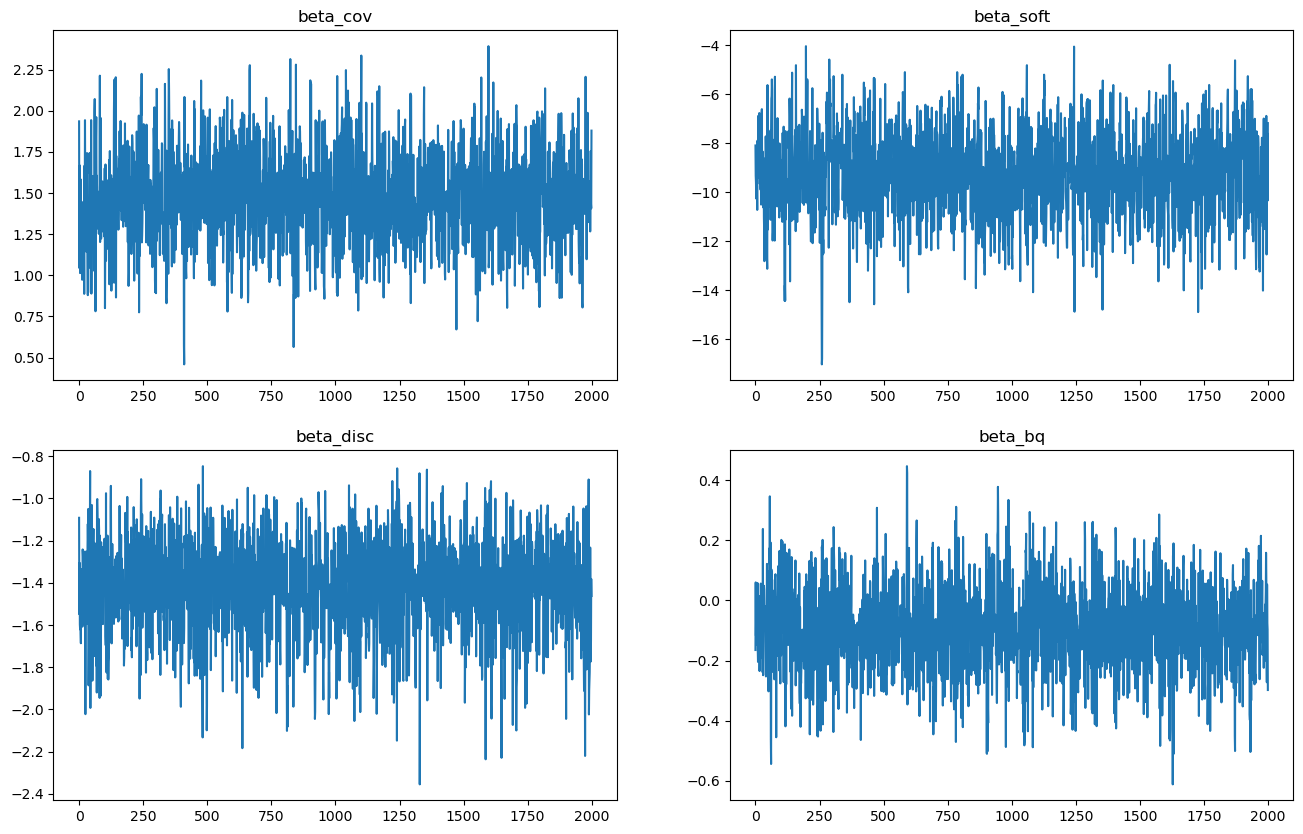

In [32]:
chain_num = 1

param_values = posterior_samples.columns[posterior_samples.columns.str.startswith('beta_')]

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
axs = axs.flatten()

for i, param in enumerate(param_values):
    
    ax = axs[i]
    
    ax.plot(posterior_samples.query("chain==@chain_num")['draw'],
            posterior_samples.query("chain==@chain_num")[param],
           )
    
    ax.set_title(param)

In [6]:
def create_model_instance(X_train, y_train):
    
    with pm.Model() as model:
        # Priors for betas (directional expectations)
        beta_cov = pm.Normal("beta_cov", mu=0.5, sigma=2)       # coverage ratio (positive)
        beta_soft = pm.Normal("beta_soft", mu=-0.5, sigma=2)    # soft clips (negative)
        beta_disc = pm.Normal("beta_disc", mu=-0.5, sigma=2)    # discordant reads (negative)
        beta_bq = pm.Normal("beta_bq", mu=0.5, sigma=2)         # base quality (positive)

        # Intercept
        intercept = pm.Normal("intercept", mu=0, sigma=2)

        # Linear predictor (logit scale)
        logit_p = (
            intercept
            + beta_cov * X_train[:, 0]
            + beta_soft * X_train[:, 1]
            + beta_disc * X_train[:, 2]
            + beta_bq * X_train[:, 3]
        )

        # Probability via logistic link
        p = pm.Deterministic("p", pm.math.sigmoid(logit_p))

        # Likelihood
        y_obs = pm.Bernoulli("y_obs", p=p, observed=y_train)
        
    return model

        
model = create_model_instance(X_train, y_train)

Sampling: [y_obs]


Observed mean: 0.3556280587275693
Predictive mean (5%,50%,95%): [0.002    0.1675   0.200725]


<Axes: xlabel='y_obs'>

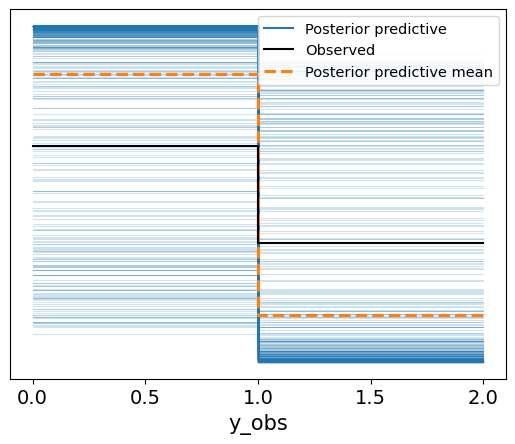

In [10]:
trace = az.from_netcdf("bayesian_model_trace.nc")

# run posterior predictive checks
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs", "p"], random_seed=42)

# y_rep: shape (draws, n_obs) or (chains*draws, n_obs)
y_rep = ppc.posterior_predictive["y_obs"]
p_draws = ppc.posterior_predictive["p"]  # probabilities per draw

# Compare observed mean vs predictive distribution of means
obs_rate = y_train.mean()
ppc_means = y_rep.mean(axis=1)   # mean y across observations per draw
print("Observed mean:", obs_rate)
print("Predictive mean (5%,50%,95%):", np.percentile(ppc_means, [5,50,95]))
# az.plot_ppc(az.from_pymc3(posterior_predictive=ppc, model=model))
az.plot_ppc(ppc, num_pp_samples=613)

In [9]:
y_rep.mean(axis=1)

<xarray.DataArray 'y_obs' (chain: 4, y_obs_dim_0: 613)> Size: 20kB
array([[0.1755, 0.0025, 0.1805, ..., 0.009 , 0.188 , 0.199 ],
       [0.148 , 0.003 , 0.166 , ..., 0.009 , 0.159 , 0.1675],
       [0.144 , 0.0015, 0.148 , ..., 0.004 , 0.164 , 0.153 ],
       [0.168 , 0.0025, 0.1765, ..., 0.01  , 0.1825, 0.177 ]],
      shape=(4, 613))
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * y_obs_dim_0  (y_obs_dim_0) int64 5kB 0 1 2 3 4 5 ... 607 608 609 610 611 612